In [22]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import phate
import scprep
import os

In [23]:
#dataset = '3_branches'
dataset = '2_branches'

In [24]:
colors = {'mustard': '#E1AD01', 'berry': '#AC2F3D', 'teal': '#216E76', 'purple':'#502A4F', 'forest': '#065535', 'light forest': '#519167',
          'light yellow': '#E3BC81', 'light berry': '#c7505d', 'light teal': '#81ABA1', 'light purple': '#95636E', 'black': '#000000', 'gray':'#808080',
          'sienna': 'sienna', 'white': 'white'}

names = ['GSPA_QR', 'DiffusionEMD', 'GAE_att_Gcell', 'GAE_noatt_Gcell', 'MAGIC',
       'Node2Vec_Gcell', 'Signals', 'GSPA', 'GAE_att_Ggene',
       'GAE_noatt_Ggene', 'Node2Vec_Ggene', 'GFMMD', 'Eigenscore']

names = ['GSPA_QR', 'DiffusionEMD', 'MAGIC', 'Signals', 'GSPA', 'GAE_att_Ggene',
       'GAE_noatt_Ggene', 'Node2Vec_Ggene', 'GFMMD', 'Eigenscore']

clist = np.array(['black', 'light yellow', 'purple', 'forest', 'mustard', 'teal',
         'berry', 'gray', 'light purple', 'light forest', 'light teal', 'sienna', 'white'])

In [25]:
results = pd.DataFrame(columns=range(4))
for model in names:
    out = pd.read_csv(f'./embedding_results/{model}/spearmanr_{dataset}.txt', sep=' ', header=None)
    out[3] = model
    results = pd.concat((results, out))
results.columns = ['run', 'metric', 'Spearman', 'model']

In [26]:
names = np.array(names)
vals = results.groupby('model').mean().loc[names]['Spearman']
names = names[np.argsort(vals)[::-1]]
clist = clist[np.argsort(vals)[::-1]]

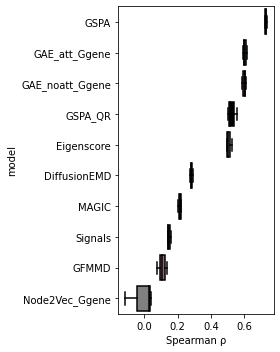

In [27]:
fig, ax = plt.subplots(figsize=(4,5))
sns.boxplot(y=results['model'],
            x=results['Spearman'].astype(float), 
            palette=[colors[c] for c in clist],
            order=names,
            ax=ax)

plt.xlabel(f'Spearman ρ')
plt.tight_layout()

if not os.path.exists(f'./figures/'):
    os.makedirs(f'./figures/')
    
fig.savefig(f'./figures/localization_embedding_{dataset}.png', dpi=200)

In [28]:
results = pd.DataFrame(columns=range(4))
for model in names:
    out = pd.read_csv(f'./uniform_results/{model}/spearmanr_{dataset}.txt', sep=' ', header=None)
    out[3] = model
    results = pd.concat((results, out))
results.columns = ['run', 'metric', 'Spearman', 'model']

In [29]:
results['Spearman'] = -1* results['Spearman'] #anticorrelation between distance to uniform and spread

In [30]:
names = ['GSPA_QR', 'DiffusionEMD', 'GAE_att_Gcell', 'GAE_noatt_Gcell', 'MAGIC',
       'Node2Vec_Gcell', 'Signals', 'GSPA', 'GAE_att_Ggene',
       'GAE_noatt_Ggene', 'Node2Vec_Ggene', 'GFMMD', 'Eigenscore']


names = ['GSPA_QR', 'DiffusionEMD', 'MAGIC', 'Signals', 'GSPA', 'GAE_att_Ggene',
       'GAE_noatt_Ggene', 'Node2Vec_Ggene', 'GFMMD', 'Eigenscore']

clist = np.array(['black', 'light yellow', 'purple', 'forest', 'mustard', 'teal',
         'berry', 'gray', 'light purple', 'light forest', 'light teal', 'sienna', 'white'])

In [31]:
names = np.array(names)
vals = results.groupby('model').mean().loc[names]['Spearman']
names = names[np.argsort(vals)[::-1]]
clist = clist[np.argsort(vals)[::-1]]

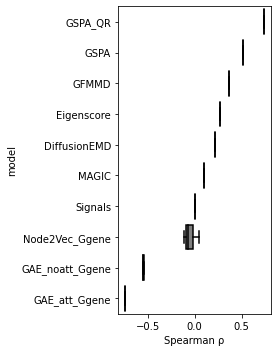

In [32]:
fig, ax = plt.subplots(figsize=(4,5))
sns.boxplot(y=results['model'],
            x=results['Spearman'].astype(float), 
            palette=[colors[c] for c in clist],
            order=names,
            ax=ax)

plt.xlabel(f'Spearman ρ')
plt.tight_layout()

if not os.path.exists(f'./figures/'):
    os.makedirs(f'./figures/')
    
fig.savefig(f'./figures/localization_uniform_{dataset}.png', dpi=200)